In [1]:
# Célula 1: Instalação das bibliotecas
!pip install psycopg2-binary sqlalchemy pandas matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 25.4 MB/s eta 0:00:00


In [2]:
# Célula 2: Importação e Configuração da Conexão
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

# --- Configurações de Acesso ao Banco de Dados ---
server = 'bigdata.dataiesb.com'
port = 5432
user = 'data_iesb'
password = 'iesb'
database = 'iesb'
schema = 'public'

# Criando a string de conexão
DATABASE_URL = f"postgresql://{user}:{password}@{server}:{port}/{database}"

# Criando o 'motor' de conexão com o banco
try:
    engine = create_engine(DATABASE_URL)
    print("Conexão com o banco de dados PostgreSQL bem-sucedida!")
except Exception as e:
    print(f"Erro ao conectar ao banco de dados: {e}")

Conexão com o banco de dados PostgreSQL bem-sucedida!


In [12]:
# Célula 3: Extração, Tratamento e Cruzamento (CORREÇÃO DE TIPO DE DADOS)
import unicodedata
import numpy as np

print("Iniciando extração e tratamento dos dados...")

# --- Função Auxiliar para Normalizar Texto (Remover Acentos) ---
def normalizar_texto(texto):
    if not isinstance(texto, str):
        return str(texto)
    nfkd = unicodedata.normalize('NFKD', texto)
    return "".join([c for c in nfkd if not unicodedata.combining(c)]).upper().strip()

# --- 1. Extrair Acidentes ---
# OBS: Se a tabela for muito grande, o pandas pode demorar. Vamos focar nos dados que temos.
query_acidentes = f"""
    SELECT pesid, municipio, uf
    FROM {schema}.acidente_transito
"""
try:
    df_acidentes = pd.read_sql(text(query_acidentes), engine)
    df_acidentes_count = df_acidentes.groupby(['uf', 'municipio']).size().reset_index(name='total_acidentes')

    # Normalizar
    df_acidentes_count['chave_municipio'] = df_acidentes_count['municipio'].apply(normalizar_texto)
    df_acidentes_count['uf'] = df_acidentes_count['uf'].astype(str).str.upper().str.strip()

    print(f"Acidentes agrupados: {df_acidentes_count.shape[0]} municípios.")
except Exception as e:
    print(f"Erro nos acidentes: {e}")

# --- 2. Extrair População ---
query_populacao = f"""
    SELECT "CO_MUNICIPIO", sum("TOTAL") as populacao_total
    FROM {schema}."Censo_20222_Populacao_Idade_Sexo"
    GROUP BY 1
"""
try:
    df_populacao = pd.read_sql(text(query_populacao), engine)
    df_populacao.rename(columns={'CO_MUNICIPIO': 'codigo_ibge_municipio'}, inplace=True)
    df_populacao['codigo_ibge_municipio'] = df_populacao['codigo_ibge_municipio'].astype(str)
except Exception as e:
    print(f"Erro na população: {e}")

# --- 3. Extrair PIB ---
query_pib = f"""
    SELECT ano_pib, codigo_municipio_dv, vl_pib_per_capta
    FROM {schema}.pib_municipios
    WHERE ano_pib = (SELECT MAX(ano_pib) FROM {schema}.pib_municipios)
"""
try:
    df_pib = pd.read_sql(text(query_pib), engine)
    df_pib.rename(columns={'codigo_municipio_dv': 'codigo_ibge_municipio'}, inplace=True)
    df_pib['codigo_ibge_municipio'] = df_pib['codigo_ibge_municipio'].astype(str)
    df_pib['vl_pib_per_capta'] = pd.to_numeric(df_pib['vl_pib_per_capta'], errors='coerce')
except Exception as e:
    print(f"Erro no PIB: {e}")

# --- 4. Extrair Tabela Base de Municípios ---
query_municipios = f"""
    SELECT codigo_municipio_dv, nome_municipio, cd_uf
    FROM {schema}.municipio
"""
try:
    df_municipio_base = pd.read_sql(text(query_municipios), engine)
    df_municipio_base.rename(columns={'codigo_municipio_dv': 'codigo_ibge_municipio', 'nome_municipio': 'municipio_nome'}, inplace=True)

    # Tratamento da Chave de Nome
    df_municipio_base['chave_municipio'] = df_municipio_base['municipio_nome'].apply(normalizar_texto)
    df_municipio_base['codigo_ibge_municipio'] = df_municipio_base['codigo_ibge_municipio'].astype(str)

    # --- CORREÇÃO DO ERRO ANTERIOR AQUI ---
    # Converter cd_uf para numérico antes de fazer o mapeamento
    df_municipio_base['cd_uf'] = pd.to_numeric(df_municipio_base['cd_uf'], errors='coerce')

    # Mapeamento UF (Agora vai funcionar pois os dados estarão como números)
    map_uf = {
        11: 'RO', 12: 'AC', 13: 'AM', 14: 'RR', 15: 'PA', 16: 'AP', 17: 'TO',
        21: 'MA', 22: 'PI', 23: 'CE', 24: 'RN', 25: 'PB', 26: 'PE', 27: 'AL', 28: 'SE', 29: 'BA',
        31: 'MG', 32: 'ES', 33: 'RJ', 35: 'SP',
        41: 'PR', 42: 'SC', 43: 'RS',
        50: 'MS', 51: 'MT', 52: 'GO', 53: 'DF'
    }
    df_municipio_base['uf'] = df_municipio_base['cd_uf'].map(map_uf)

    # Debug para confirmar a correção
    print(f"Verificação UF Base Municípios (amostra): {df_municipio_base['uf'].dropna().unique()[:5]}")

except Exception as e:
    print(f"Erro na base de municípios: {e}")

# --- 5. Cruzamento dos Dados ---

if 'df_acidentes_count' in locals() and 'df_municipio_base' in locals():
    print("\nTentando cruzar dados...")

    # Merge 1: Acidentes + Base Municípios (Usando 'chave_municipio' sem acentos)
    df_merged = pd.merge(
        df_acidentes_count,
        df_municipio_base,
        on=['uf', 'chave_municipio'],
        how='inner'
    )

    print(f"Resultado Merge 1 (Municípios identificados): {df_merged.shape[0]}")

    if df_merged.shape[0] > 0:
        # Merge 2: + PIB
        df_merged = pd.merge(
            df_merged,
            df_pib[['codigo_ibge_municipio', 'vl_pib_per_capta']],
            on='codigo_ibge_municipio',
            how='inner'
        )

        # Merge 3: + População
        df_merged = pd.merge(
            df_merged,
            df_populacao[['codigo_ibge_municipio', 'populacao_total']],
            on='codigo_ibge_municipio',
            how='inner'
        )

        # Filtrar
        df_analise = df_merged[
            (df_merged['populacao_total'] > 0) &
            (df_merged['vl_pib_per_capta'].notna())
        ].copy()

        print("\n--- SUCESSO ABSOLUTO! ---")
        print(f"DataFrame final gerado com {df_analise.shape[0]} linhas.")
        print("Agora você pode rodar as Células 4 e 5 para ver o gráfico!")
    else:
        print("\nATENÇÃO: Ainda deu 0 linhas. Verifique se os nomes dos municípios estão batendo (ex: BRASILIA vs BRASILIA).")
        print(f"Exemplo Acidente: {df_acidentes_count[['uf', 'chave_municipio']].head(3)}")
        print(f"Exemplo Municipio: {df_municipio_base[['uf', 'chave_municipio']].head(3)}")
else:
    print("Falha na criação do DataFrame final.")

Iniciando extração e tratamento dos dados...
Acidentes agrupados: 21 municípios.
Verificação UF Base Municípios (amostra): ['RO' 'AC' 'AM' 'RR' 'PA']

Tentando cruzar dados...
Resultado Merge 1 (Municípios identificados): 21

--- SUCESSO ABSOLUTO! ---
DataFrame final gerado com 21 linhas.
Agora você pode rodar as Células 4 e 5 para ver o gráfico!


In [13]:
# Célula 4: Cálculo da Taxa de Acidentes
# Fórmula: (Total de Acidentes / População Total) * 100.000

if 'df_analise' in locals() and not df_analise.empty:
    df_analise['taxa_acidentes_100k'] = (df_analise['total_acidentes'] / df_analise['populacao_total']) * 100000

    # Ordenar para ver quem tem a maior taxa
    df_exibicao = df_analise[['uf', 'chave_municipio', 'populacao_total', 'vl_pib_per_capta', 'total_acidentes', 'taxa_acidentes_100k']]
    print("--- Top 5 Municípios com Maior Taxa de Acidentes ---")
    print(df_exibicao.sort_values(by='taxa_acidentes_100k', ascending=False).head(5))
else:
    print("O DataFrame 'df_analise' não está pronto. Verifique a Célula 3.")

--- Top 5 Municípios com Maior Taxa de Acidentes ---
    uf  chave_municipio  populacao_total  vl_pib_per_capta  total_acidentes  \
1   GO        ABADIANIA            17232          21334.94              869   
19  GO         VILA BOA             4215          27886.97              201   
20  GO    VILA PROPICIO             5815          51845.31              209   
3   GO         ALEXANIA            27008          39776.23              764   
10  GO  FLORES DE GOIAS            13744          14409.16              377   

    taxa_acidentes_100k  
1           5042.943361  
19          4768.683274  
20          3594.153052  
3           2828.791469  
10          2743.015134  



--- RESULTADO ESTATÍSTICO ---
Coeficiente de Correlação (Pearson): 0.0083
P-valor: 0.9715
Interpretação: Correlação Fraca Positiva
------------------------------------------


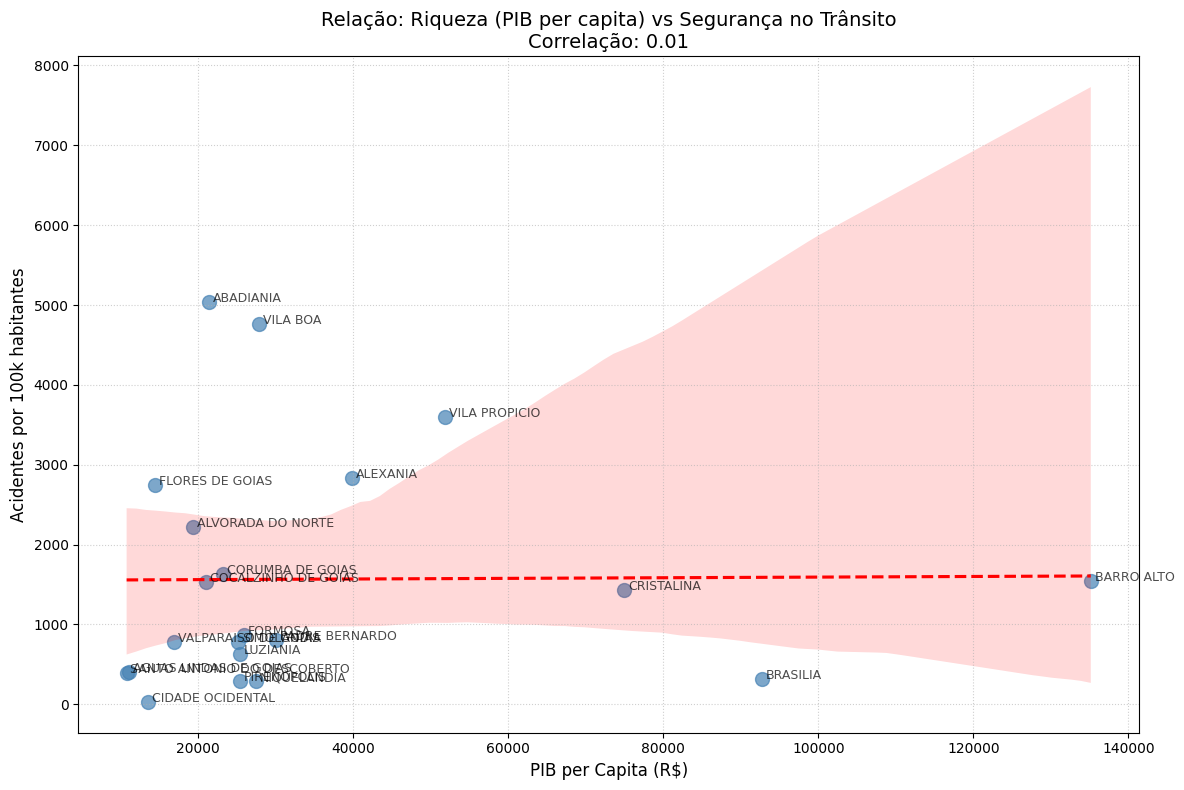

In [14]:
# Célula 5: Análise de Correlação e Gráfico de Dispersão
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

if 'df_analise' in locals() and not df_analise.empty:

    # 1. Cálculo da Correlação de Pearson e p-valor
    # O p-valor nos diz se a correlação é estatisticamente significativa
    corr_coef, p_value = pearsonr(df_analise['vl_pib_per_capta'], df_analise['taxa_acidentes_100k'])

    print(f"\n--- RESULTADO ESTATÍSTICO ---")
    print(f"Coeficiente de Correlação (Pearson): {corr_coef:.4f}")
    print(f"P-valor: {p_value:.4f}")

    interpretacao = ""
    if abs(corr_coef) < 0.3: interpretacao = "Fraca"
    elif abs(corr_coef) < 0.7: interpretacao = "Moderada"
    else: interpretacao = "Forte"

    tipo = "Positiva" if corr_coef > 0 else "Negativa"
    print(f"Interpretação: Correlação {interpretacao} {tipo}")
    print("------------------------------------------")

    # 2. Visualização
    plt.figure(figsize=(12, 8))

    # Plotar pontos
    sns.regplot(
        x='vl_pib_per_capta',
        y='taxa_acidentes_100k',
        data=df_analise,
        scatter_kws={'s': 100, 'alpha': 0.7, 'color': 'steelblue'}, # Estilo dos pontos
        line_kws={'color': 'red', 'linestyle': '--'} # Linha de tendência
    )

    # Adicionar Rótulos (Nomes dos Municípios) aos pontos
    # Isso ajuda a identificar Brasília e outros destaques
    for i in range(df_analise.shape[0]):
        plt.text(
            df_analise.vl_pib_per_capta.iloc[i] + 500, # Ajuste leve na posição X
            df_analise.taxa_acidentes_100k.iloc[i],
            df_analise.chave_municipio.iloc[i],
            fontsize=9,
            alpha=0.7
        )

    plt.title(f'Relação: Riqueza (PIB per capita) vs Segurança no Trânsito\nCorrelação: {corr_coef:.2f}', fontsize=14)
    plt.xlabel('PIB per Capita (R$)', fontsize=12)
    plt.ylabel('Acidentes por 100k habitantes', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

else:
    print("Erro: DataFrame vazio.")